In [8]:
import open3d as o3d

visualization = []

feature_path = "surface/surface1.stl"
source_workpiece = "surface/workpiece.stl"


mesh = o3d.io.read_triangle_mesh(source_workpiece)
mesh.compute_vertex_normals()
mesh_surface = o3d.io.read_triangle_mesh(feature_path)
mesh_surface.compute_vertex_normals()

pcd = o3d.geometry.PointCloud()
pcd = mesh.sample_points_poisson_disk(number_of_points=400)
pcd.paint_uniform_color([0, 1, 0])
visualization.append(pcd)

pcd_surface = o3d.geometry.PointCloud()
pcd_surface = mesh_surface.sample_points_poisson_disk(number_of_points=4000)
pcd_surface.paint_uniform_color([1, 0, 0])
visualization.append(pcd_surface)

world_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=10, origin=[0, 0, 0])
visualization.append(world_frame)


o3d.visualization.draw_geometries(visualization)



In [9]:
o3d.visualization.draw_geometries([pcd_surface])


In [1]:
import open3d as o3d
import numpy as np

# Load the already simulated point cloud
pcd_path = "viewpoints_candidate/testing_data/test_3_dofconsistency_15/viewpoint_simulated_4.pcd"
simulated_pcd = o3d.io.read_point_cloud(pcd_path)
simulated_pcd.paint_uniform_color([0, 1, 0]) # Gray for the base simulated points

# feature_path = "surface/surface1.stl"
feature_mesh = o3d.io.read_triangle_mesh(feature_path)
feature_mesh.compute_vertex_normals()
feature_pcd = o3d.geometry.PointCloud()
feature_pcd = feature_mesh.sample_points_poisson_disk(number_of_points=1000)
feature_pcd.paint_uniform_color([1, 0, 0]) # Red for the reference surface

# --- Calculate Intersection ---
# Compute distances from simulated_pcd to feature_pcd
dists = simulated_pcd.compute_point_cloud_distance(feature_pcd)
dists = np.asarray(dists)

# Find points within a very small threshold
distance_threshold = 1 
intersection_indices = np.where(dists < distance_threshold)[0]
intersection_pcd = simulated_pcd.select_by_index(intersection_indices)

# Paint the intersecting points blue
intersection_pcd.paint_uniform_color([0, 0, 1])

print(f"Found {len(intersection_indices)} intersecting points!")

# Visualize it
o3d.visualization.draw_geometries([simulated_pcd, feature_pcd])
o3d.visualization.draw_geometries([intersection_pcd])


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


NameError: name 'feature_path' is not defined

In [4]:
import open3d as o3d
import numpy as np

visualization = []

# Load the specific point cloud
pcd_path = r"processed_data/test_3_dofconsistency_15/viewpoint_simulated_4.pcd"
actual_pcd = o3d.io.read_point_cloud(pcd_path)
actual_pcd.paint_uniform_color([0, 1, 0])

# Load the transformation matrix
transform_path = r"evaluation_result/test_3_dofconsistency_15/merge_full_transformation.npy"
transformation_matrix = np.load(transform_path)

# --- Compute and apply the INVERSE transformation ---
inverse_transformation = np.linalg.inv(transformation_matrix)
actual_pcd.transform(inverse_transformation)

# Load the surface mesh and sample points
# feature_path = "surface/surface1.stl"
# feature_mesh = o3d.io.read_triangle_mesh(feature_path)
# feature_mesh.compute_vertex_normals()
# feature_pcd = o3d.geometry.PointCloud()
# feature_pcd = feature_mesh.sample_points_poisson_disk(number_of_points=1000)
# feature_pcd.paint_uniform_color([1, 0, 0]) # Red for the reference surface

# --- Calculate Intersection ---
dists = actual_pcd.compute_point_cloud_distance(feature_pcd)
dists = np.asarray(dists)

# distance_threshold = 2 
intersection_indices = np.where(dists < distance_threshold)[0]
intersection_pcd = actual_pcd.select_by_index(intersection_indices)

# Paint the intersecting points blue
intersection_pcd.paint_uniform_color([0, 0, 1])

print(f"Found {len(intersection_indices)} intersecting points!")

# Add all components to the visualization
visualization.append(actual_pcd)
visualization.append(feature_pcd)

world_frame = o3d.geometry.TriangleMesh.create_coordinate_frame(size=10, origin=[0, 0, 0])
# visualization.append(world_   frame)

# Visualize everything together, and then visualize just the intersection
o3d.visualization.draw_geometries(visualization, window_name="Viewpoint Simulated 21 - Inverse Transformed")
o3d.visualization.draw_geometries([intersection_pcd], window_name="Intersection Only")

Found 151 intersecting points!


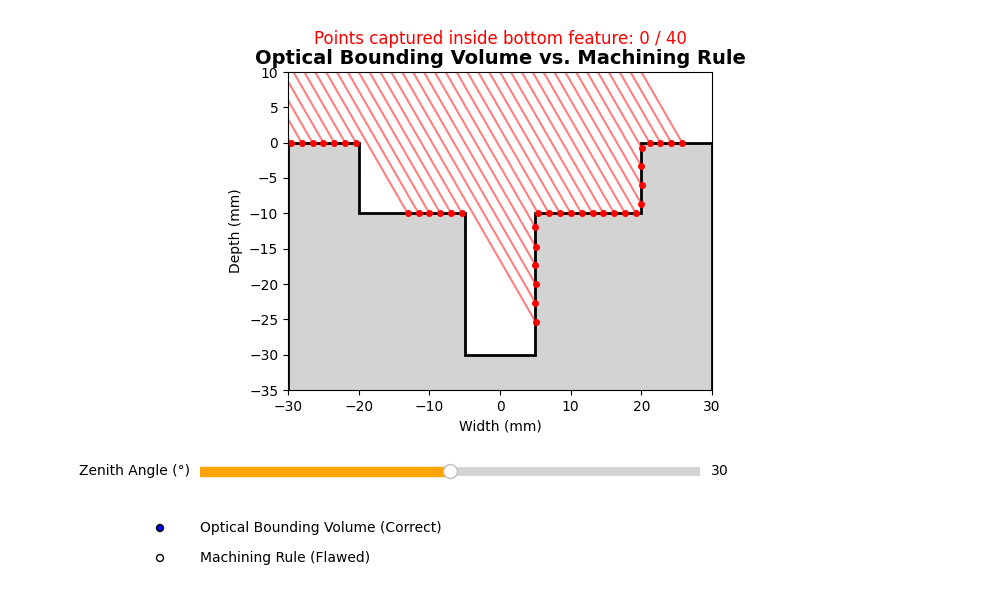

In [ ]:
# If running in Jupyter Notebook, uncomment the line below:
# %matplotlib widget 
%matplotlib tk


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, RadioButtons
from matplotlib.patches import Polygon

# --- Geometry Definitions ---
# Full Optical Bounding Volume (Stepped Pocket)
poly_full = np.array([
    [-30, 0], [-20, 0], [-20, -10], [-5, -10], [-5, -30], 
    [5, -30], [5, -10], [20, -10], [20, 0], [30, 0], 
    [30, -40], [-30, -40]
])

# Machining Rule (Bottom Pocket Only, Top deleted)
poly_mach = np.array([
    [-30, -10], [-5, -10], [-5, -30], 
    [5, -30], [5, -10], [30, -10], 
    [30, -40], [-30, -40]
])

# --- Setup Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
plt.subplots_adjust(left=0.1, bottom=0.35)
ax.set_xlim(-30, 30)
ax.set_ylim(-35, 10)
ax.set_aspect('equal')
ax.set_title("Optical Bounding Volume vs. Machining Rule", fontsize=14, fontweight='bold')
ax.set_xlabel("Width (mm)")
ax.set_ylabel("Depth (mm)")

# Create the solid metal patch
metal_patch = Polygon(poly_full, closed=True, facecolor='lightgray', edgecolor='black', lw=2)
ax.add_patch(metal_patch)

# Line object for the rays
rays_lines = []

# --- UI Controls ---
ax_angle = plt.axes([0.2, 0.2, 0.5, 0.03])
slider_angle = Slider(ax_angle, 'Zenith Angle (°)', 0.0, 60.0, valinit=30.0, color='orange')

ax_radio = plt.axes([0.1, 0.02, 0.4, 0.15], frameon=False)
radio_mode = RadioButtons(ax_radio, ('Optical Bounding Volume (Correct)', 'Machining Rule (Flawed)'))

# --- Optical Physics Engine ---
def get_ray_intersection(start_x, angle_deg, mode):
    angle_rad = np.radians(angle_deg)
    
    # Generate discrete steps along the ray path
    y_test = np.linspace(10, -35, 500)
    x_test = start_x + (10 - y_test) * np.tan(angle_rad)
    
    for i in range(len(y_test)):
        x, y = x_test[i], y_test[i]
        
        if mode == 'Optical Bounding Volume (Correct)':
            # Collision rules for the full stepped pocket
            if y <= 0 and (x <= -20 or x >= 20): return x, y       # Hits top surface
            if y <= -10 and (x <= -5 or x >= 5): return x, y       # Hits upper pocket floor
            if y <= -30 and (-5 < x < 5): return x, y              # Hits lower pocket floor
        else:
            # Collision rules for ONLY the bottom pocket
            if y <= -10 and (x <= -5 or x >= 5): return x, y       # Hits floating surface
            if y <= -30 and (-5 < x < 5): return x, y              # Hits lower pocket floor
            
    return x_test[-1], -35

# --- Update Logic ---
def update(val):
    angle = slider_angle.val
    mode = radio_mode.value_selected
    
    # Update solid geometry
    if mode == 'Optical Bounding Volume (Correct)':
        metal_patch.set_xy(poly_full)
    else:
        metal_patch.set_xy(poly_mach)
        
    # Clear old rays
    while len(ax.lines) > 0:
        ax.lines[0].remove()
        
    bottom_hits = 0
    total_rays = 0
        
    # Cast 40 parallel rays (simulating active stereo projector)
    for start_x in np.linspace(-40, 20, 40):
        total_rays += 1
        end_x, end_y = get_ray_intersection(start_x, angle, mode)
        
        # Determine ray color based on what it hits
        if end_y <= -29:  # Hit the bottom pocket
            color = 'green'
            bottom_hits += 1
        else:
            color = 'red'
            
        # Draw the ray and the impact point
        ax.plot([start_x, end_x], [10, end_y], color=color, alpha=0.5, lw=1.5)
        ax.plot(end_x, end_y, marker='o', color=color, markersize=4)

    # Dynamic text update to prove the thesis point
    fig.suptitle(f"Points captured inside bottom feature: {bottom_hits} / {total_rays}", 
                 fontsize=12, color='green' if bottom_hits > 0 else 'red', y=0.95)
                 
    fig.canvas.draw_idle()

# Link UI to update function
slider_angle.on_changed(update)
radio_mode.on_clicked(update)

# Initialize plot
update(0)
plt.show()